Fetching ETF data...


[*********************100%***********************]  1 of 1 completed


Loading WIBOR data...

--- ETF: First Rows ---
Price       etf_price
Date                 
2019-07-29  71.849998
2019-07-30  71.440002
2019-07-31  71.550003
2019-08-01  71.989998
2019-08-02  69.639999

--- ETF: Number of rows --- 1810

--- ETF: Data Information ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1810 entries, 2019-07-29 to 2026-09-11
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   etf_price  1810 non-null   float64
dtypes: float64(1)
memory usage: 28.3 KB
None

--- ETF: Descriptive statistics ---
Price    etf_price
count  1810.000000
mean    106.417630
std      26.188250
min      54.660000
25%      90.585001
50%      99.900002
75%     127.025002
max     169.619995

--- ETF: Missing values ---
Price
etf_price    0
dtype: int64
Maximum gap between dates: 6.0 days
Number of unusual gaps (> 4 days): 11
Price       days_gap
Date                
2020-04-14       5.0
2020-12-28       5.0
2021-01-04       5.0
2021-

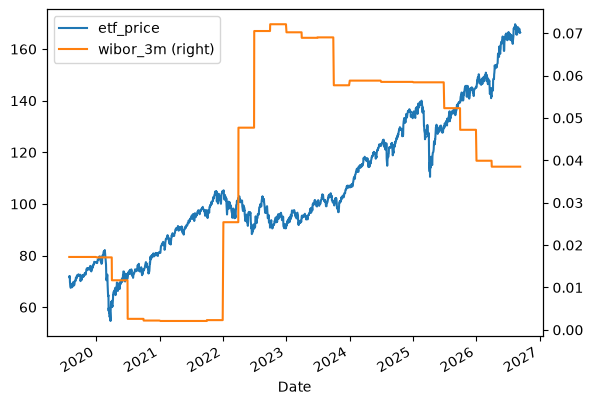

In [5]:
from pathlib import Path
import pandas as pd
import transformation as tr

# ==========================================
# 1. FETCH & LOAD DATA VIA TRANSFORMATION MODULE
# ==========================================
print("Fetching ETF data...")
df_etf = tr.fetch_etf_data("VWCE.DE", start_date="2016-01-01")

print("Loading WIBOR data...")
# Relative path adjustment for notebooks/scripts inside src/
wibor_path = Path.cwd().parent / "data" / "data_raw_wibor_3m.csv"
df_wibor = tr.load_wibor_data(file_path=wibor_path)

# ==========================================
# 2. ETF EXPLORATION
# ==========================================
print("\n--- ETF: First Rows ---")
print(df_etf.head())
print("\n--- ETF: Number of rows ---", len(df_etf))
print("\n--- ETF: Data Information ---")
print(df_etf.info())
print("\n--- ETF: Descriptive statistics ---")
print(df_etf.describe())
print("\n--- ETF: Missing values ---")
print(df_etf.isna().sum())

# Long time gaps
df_etf["days_gap"] = df_etf.index.to_series().diff().dt.days
# Filter for gaps larger than 4 days 
large_gaps = df_etf[df_etf["days_gap"] > 4]
# Print results
print(f"Maximum gap between dates: {df_etf['days_gap'].max()} days")
print(f"Number of unusual gaps (> 4 days): {len(large_gaps)}")

if not large_gaps.empty:
    print(large_gaps[["days_gap"]])

# ==========================================
# 3. WIBOR EXPLORATION
# ==========================================
print("\n--- WIBOR: First Rows ---")
print(df_wibor.head())
print("\n--- WIBOR: Number of rows---", len(df_wibor))
print("\n--- WIBOR: Data Information ---")
print(df_wibor.info())
print("\n---WIBOR: Descriptive statistics ---")
print(df_wibor.describe())
print("\n---WIBOR: Missing values---")
print(df_wibor.isna().sum())


# ==========================================
# 4.DATA EXPLORATION
# ==========================================

# ETF Price + Wibor chart
pd.merge_asof(df_etf, df_wibor, left_index=True, right_index=True)[
    ["etf_price", "wibor_3m"]
].plot(secondary_y="wibor_3m")

#Outliers 
# 1. Calculate daily percentage returns (price change day-to-day)
df_etf["returns"] = df_etf["etf_price"].pct_change()

# 2. Calculate mean and standard deviation
mean_return = df_etf["returns"].mean()
std_return = df_etf["returns"].std()

# 3. Find days where returns deviate by more than 3 standard deviations
outliers = df_etf[abs(df_etf["returns"] - mean_return) > 3 * std_return]

# 4. Display the results
print(f"Number of outlier days: {len(outliers)}")
print(outliers[["etf_price", "returns"]])